## Ash Kuinkel ~ cosc102 assignment 1

### Brief Overview: 
This program is crafted in two separate sections to answer the two questions as provided in the task description :

1) **Predator-Prey Population Dynamics** - We are given the relationship between populations of prey (rabbit) and predator
(fox) species (i.e. as predators increase, prey decrease & vice versa), and it is explicitly modelled through differential
equations. For this task, simplicity is prioritised & we are provided the required equations. Under some assumptions; foxes
shall only eat rabbits, unlimited population growth of both species, no external influences, & given constant values (c,d,f,g)
representative of predation/reproduction rates, we need to model the population of our prey & predator in a visual manner, with the help of python/matplotlib/numpys etc. 

2) **Sampling a Binomial Distribution** - We are told to simulate the process of a Galtoan board & also create a histogram as
well as a Kernel Density Plot to show the resulting distribution from our simulation. This question requires much more thought
than the first one, at first glance it is easy to miss the importance of understanding how everything including the variables
r, n, p and the interval we generate our random number between are very closely related and what the effect of modifying these 
variables is. However, once we understand this, the question becomes very interesting and we see the roles of all the variables
and the interval at play. Furthermore, this thought is prompted to us via the questions that are asked in the second question, 
i.e. questions about effects on resulting distribution by modifying n the number of experiments/rows & p the probability of the 
balls going to the right. This is a very well-formed question which rewards understanding along with implementation rather than
just the pure implementation.


# Question 1 - Predator-Prey Population Dynamics 

### <u>Imports/Initialisations</u>

We first begin our program by importing the required libraries/modules. Matplotlib is a library whose main purpose is to help us in crafting visualisations in python such as histograms, bar charts, scatter plots, line graphs etc. This is the only one we really need for the first part of this assignment, i.e. question 1. More specifically, we are using the pyplot module which helps us in creating and customising our figure/axes with the methods provided. The reason we've imported it saying **import as plt** is so that we don't have to repeat matplotlib.pyplot every time we want to call a method. Instead we can just refer to it as **plt**. This is reflected in the later parts of the code.

In [2]:
# imports:
import matplotlib.pyplot as plt

Like solving a problem in any other domain, we follow the same procedure here. Our first step towards making an effort to tackle the problem is always noting the known/gathered information we have at our disposal. This includes the initial values we are given for the populations and the constants. Note that the variable isn't called initial_pop_foxes or initial_pop_rabbits as it wouldn't be refelctive of the variable at all states of the program.

In [3]:
# Rather than having to create 4 different lines for the constant, we can declare them like this:
c,d,f,g = 0.000005,0.3,0.5,0.00001 # This is known as tuple unpacking
pop_foxes = 35000
pop_rabbits = 70000

From our content, i.e. jupyter notebooks from the lectures, we know that to plot the graph of our population models, we should have a list of int/float values that we wish to plot. However, instead of initialising the lists here, it is much better that we do it inside the core function and then just return the lists from the function. This ensures that our core function will be fully reusable and if we do choose to call it e.g. twice in a row with different values doesn't cause any problems.

Note that in the initialisation of the lists in the core function below, we must first put the initial values into the lists. This is an important point in our discussion here. Say we didn't initialise the lists to e.g. 35,000 & 70,000, it would cause a problem as the first value wouldn't be the initial values of the populations but would rather be the populations after the first time period.

Note that I have named the variables to be foxes/rabbits_sequence_terms. This is actually the correct mathematical name for the model we have been provided in the task description (recursive sequence).

### <u>Core Sequence Logic</u>

We now move onto the chunk of our logic here which ensures that we are using the recursive model provided in the task description to generate 20 points (which are stored in the list fox/rabbit_sequence_terms) for the respective populations and this is the entire dataset required for this problem. Note that this is implemented as a resuable function with adequate documentation through the use of docstrings, as required by the quality of solution part in the marking rubric:

In [4]:
def predator_prey_data_generator(c:float,d:float,f:float,g:float,pop_foxes:float,pop_rabbits:float,time_step:int) -> tuple[list[float],list[float]]:
    '''
    Outputs required dataset for population of prey & predators after 20 time-steps w/ provided model.
    
    Args:
      c (float) : Constant value representing either reproduction or predation rate.
      d (float) : Constant value representing either reproduction or predation rate.
      f (float) : Constant value representing either reproduction or predation rate.
      g (float) : Constant value representing either reproduction or predation rate.
      pop_foxes (float) : Initial population of foxes.
      pop_rabbits (float) : Initial population of rabbits.
      time_step (int) : Determines over how much time, the model iterates to. 
    
    Returns:
      (list[float], list[float]) : Tuples containing the population sequences for foxes and rabbits.
    '''
    
    foxes_sequence_terms = [pop_foxes]
    rabbits_sequence_terms = [pop_rabbits]
    
    i = 0 # initialise var i to keep track of the amout of times we have iterated through the sequence
    while (i < time_step):
        curr_fox_pop = pop_foxes
        curr_rabbit_pop = pop_rabbits
        
        #Model for population of foxes as provided in the question description:
        pop_foxes = (((c * curr_rabbit_pop) - d) * curr_fox_pop) + curr_fox_pop 
        foxes_sequence_terms.append(pop_foxes) #add term to fox population arr
        
        #Model for population of rabbits as provided in the question description:
        pop_rabbits = ((f - (g * curr_fox_pop)) * curr_rabbit_pop) + curr_rabbit_pop
        rabbits_sequence_terms.append(pop_rabbits) # add term to rabbit population arr
        
        i+=1 # incrementing our variable i with short hand python syntax, i.e. i+=1 instead of i = i + 1
    
    return foxes_sequence_terms, rabbits_sequence_terms

A very important mistake I first made here at first was initialising the models to just:

```python 
pop_foxes = (((c * pop_rabbits) - d) * fox_pop) + fox_pop
pop_rabbits = ((f - (g * pop_foxes)) * pop_rabbits) + pop_rabbits
```

Notice that when we work out pop_foxes, everything would be fine and we would get the intended
value. However, once we pass in that pop_foxes value to the pop_rabbits, we're actually passing the 
updated pop_foxes value. This led me to getting the wrong graph points at first. The solution for this 
problem was to initialise 2 variables to hold the current fox/rabbit population and pass those so that
the updated pop_foxes isn't passed into pop_rabbits. This is made evident within our function, through the two lines:

```python
curr_fox_pop = pop_foxes
curr_rabbit_pop = pop_rabbits
```


*We can now verify that we have populated our lists with the appropriate values, as such:*

In [5]:
#calling our function with the initialised values as such & caputring return values in 2 vars:
foxes_sequence_terms, rabbits_sequence_terms = predator_prey_data_generator(c, d, f, g, pop_foxes, pop_rabbits, 20)

In [6]:
print(foxes_sequence_terms)

[35000, 36750.0, 40516.875, 46830.67027734375, 56152.703760730394, 68218.52160635527, 80715.90648486368, 88397.24599090994, 86080.05152379734, 74774.30367521863, 60403.23812185969, 47180.90226806577, 36454.88934746249, 28241.98161144092, 22165.15434625838, 17804.98750911231, 14814.4117846488, 12955.893168746981, 12126.221370570143, 12409.632637881228, 14219.514014718696]


In [7]:
print(rabbits_sequence_terms)

[70000, 80500.0, 91166.25, 99811.6594453125, 102975.02003478922, 96639.27210449587, 79033.02543591382, 54757.31525086, 33732.01421596924, 21561.48610683289, 16219.778061836034, 14532.395927226073, 14942.078371206204, 16965.99942037496, 20657.46469406297, 26407.438107631562, 34909.316104906975, 47192.36431837482, 64674.35417266772, 89168.97590203732, 122687.9215166523]


So this concludes the core logic function of the first question, and we are now able to continue and plot these points we've managed to gather!

### <u>Plotting Logic</u>

*Note that attempting to create a function whose params would be highly specific, e.g. x_label, y_label is very much a tedious task, and defeats the point of being able to use the methods available. Hence, there is no need of a function for our plotting logic. Also the entire plotting logic could've been in one cell, but explanations were provided for the blocks of code, hence why are split into different cells (& why we had to prevent displaying plot until all changes took place).*

Initialise the structural figure containing just a single plot axes & plot the points we managed to gather within the lists *fox_sequence_terms* and *rabbits_sequence_terms* by doing as follows:

In [8]:
fig,ax = plt.subplots()

# plotting fox population, w/label foxes for  legend and colour red as required by task:
ax.plot(foxes_sequence_terms,'r',label='Foxes') 
# plotting rabbit population, w/label rabbits for  legend and colour green as required by task:
ax.plot(rabbits_sequence_terms,'g',label='Rabbits')

plt.close(fig) # Don't display until we make all changes, else it wont be truly representative of the plot we have made..

Including the legend with the loc to best, i.e. we let it automatically decide where the best position for the legend is within our graph, & also setting the title of the graph (in bold as required):

In [9]:
ax.legend(loc='best',fontsize='x-small')

ax.set_title("Predator-Prey populations over time",weight='bold')

Text(0.5, 1.0, 'Predator-Prey populations over time')

Formatting the y axis of the graph to include label, and match the intervals as shown in the example plot within task description:

In [10]:
ax.set_ylabel("Population")
ax.set_yticks([0,20000,40000,60000,80000,100000,120000])

Formatting x axis of graph to include label, match intervals shown in example (i.e. 20) 

In [11]:
ax.set_xlabel("Time Step")
x_label_steps = list(range(21))
ax.set_xticks(x_label_steps)
ax.set(xlim=(0,20)) # configure graph to display from 0-20 label, no other extra space needed..

[(0.0, 20.0)]

Configuring colour of the labels, remove the label marks that would otherwise be present, and add faint grid (configured via alpha value) to try and match the example plot exactly:

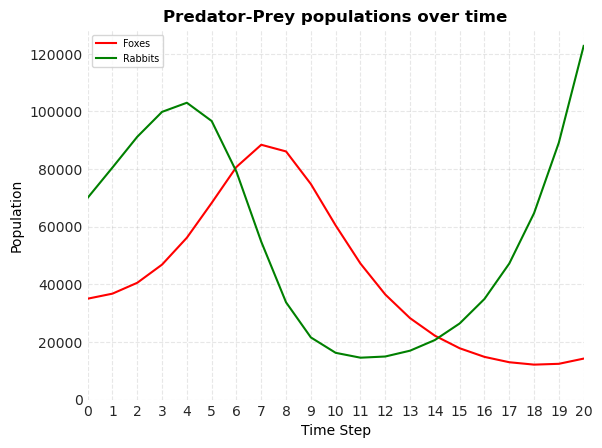

In [12]:
ax.tick_params(length=0,axis='both',labelcolor=(38/255,38/255,38/255)) #Normalisation with the /255

#Disable the tick marks on all the axes:
for spine in ax.spines.values(): 
    spine.set_visible(False)

ax.grid(alpha=0.3,linestyle='--')

display(fig) # Displaying the final plot

Our final step is to now save the plot to a file as required by the assessment task:

In [13]:
#saving figure to file:
fig.savefig("AKuinkelAT1Q1-Predator-Prey-model.png")

# Question 2 - Sampling a Binomial Distribution

### <u>Imports/Initialisations</u>

Once again, we begin with the required imports for our program within the top of the file, we require matplotlib.pyplot for the plot (purpose/function of this explained in previous question), the random module which allows us to generate random numbers, the numpy library which allows us to format our data in a manner which e.g. scikit accepts & the KDE from scikit.

In [14]:
# imports:
import random
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KernelDensity

Initialising the variables we need i.e. n & p, as required by the question. Note that trials is initialised & returned within the main logic function for this program:

In [15]:
n = 12 # number of rows in the galton board
p = 0.5 # probablitiy of a ball moving to the right/left of any pin is 50/50, let's assume p is the probability of a ball moving to the right

### <u>Core Logic (Simulating Process of Galton Board)</u>

We define our function galton_process() here and we follow the algorithm that the question gives us which is just:

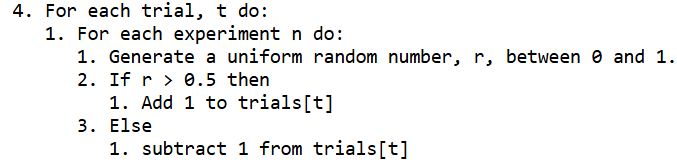

Note that the task description uses r > 0.5. However let's think about what this actually means. It's saying that if r (random uniform num between interval) is greater than some threshold (0.5 in the task description) then the ball will go right, else ball will go left. But what is the threshold? It's simply an exact point at which the outcomes are separated, e.g:

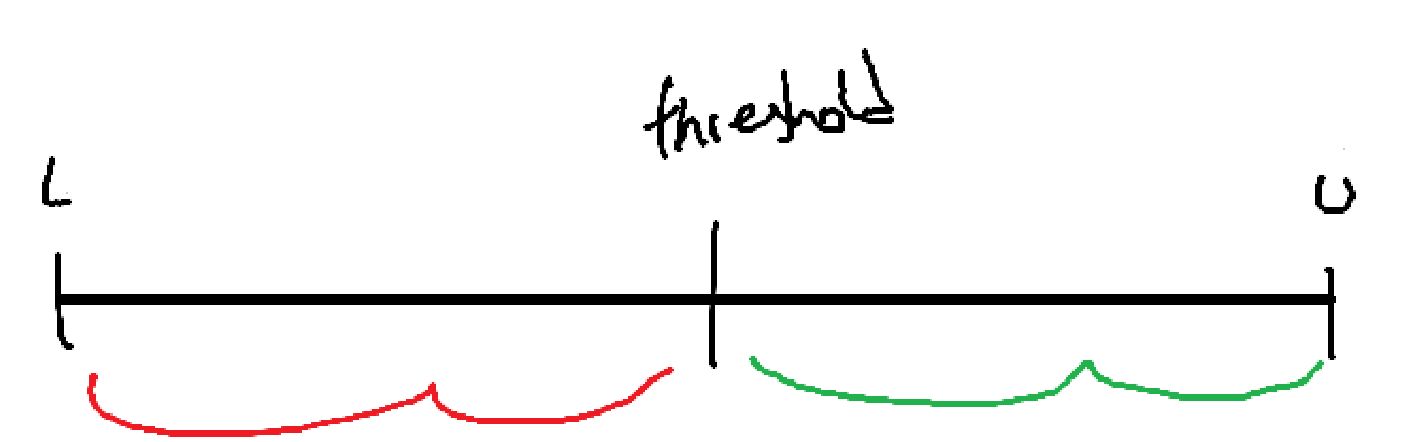

*Note that L & U Represent the interval, L standing for lower & U standing for upper*

anything past the threshold, even by a little bit will have outcome green & anything below threshold even by a little bit will have outcome red. So we now see that our given example threshold is 0.5. So this represents a 50/50 split resulting in the symmetric distribution we expect when our interval is between 0 & 1. However what if we used the same 0.5 threshold with the interval set at say 0-10. How would this affect the distribution? we'd have a negatively skewed distribution as r > 0.5 for interval 0-10 catches 95% balls to the right and only about 5% left. This may not be what we wanted, we may've wanted the 50/50 split even with the interval being 0-10. How could we ensure that? Our threshold would have to change. Also note we can't just blindly set our threshold to be like p, e.g. r < p. Whilst it does indeed produce the correct result (explanation for this coming soon), we can't really compare a random value generated to a probability without having the probability scaled to match our interval. 

So how do we work the threshold out? e.g. Lets think of throwing paper planes in a straight line between the interval [L,U] where L is your current position and U is 200m away in a straight line from you. Note that the paper plane is equally likely to land anywhere on this interval. So, if you have a threshold, then we ask what is the probability that our plane crosses this threshold, i.e. 
P ( r > threshold), so due to it being uniform you would have to see where the threshold is relative to the entire interval [L,U] right? So P ( r > threshold ) would be the (length of the area that allows us to say we've crossed threshold)/(total length of our interval).. which means that P ( r > threshold ) has to be (U - T) / (U-L) where T = threshold. So this allows us to find the threshold in terms of p and the interval (by rearranging it, as we've done below)...

Going back to the example of wanting a 50/50 split for interval 0-10, we can now work the threshold out in such way, i.e. threshold = U - p*(U-L) = 10-0.5(10-0) = 5. So we'd need to use r > 5 for our 50/50 split.

In [16]:
def galton_process(num_of_trials:int, n:int, p:float, interval_lower_bound: int = 0, interval_upper_bound: int = 1) -> list:
    '''
    Simulates Galton board process for given amount of trials, rows, & probability of moving right. Also allows specification of interval bounds for generating random numbers.
    
    Args:
      num_of_trials (int) : Number of trials to simulate.
      n (int) : Number of rows in the Galton board.
      p (float) : Probability of a ball moving to the right at each pin.
      interval_lower_bound (int) : Lower bound for generating random numbers.
      interval_upper_bound (int) : Upper bound for generating random numbers.
      
    Returns:
      list : List containing the final positions of the ball after each trial.
    '''
    trials = [0] * num_of_trials # initialising trials to hold num_of_trials amount of 0's.
    
    for t in range(num_of_trials): # i.e. for each trial t
        for _ in range(n): # i.e. for each experiment n (also note we use _ as variable name, indicating that the loop variable won't be used within the loop)
            # Generating random uniform number between 0 & 1:
            r = random.uniform(interval_lower_bound,interval_upper_bound)
            threshold = interval_upper_bound - p*(interval_upper_bound - interval_lower_bound)
            if (r > threshold): 
                trials[t] += 1 # ball moves right
            else:
                trials[t] -= 1 # ball moves left
    
    return trials

trials = galton_process(1000,n,p) # Calling our re-usable function with the num_of_trials & vars n/p we initialised earlier.         

This is our trials list generated, we now have what we need to start plotting our histogram and the KDE.

### <u>Plotting Logic</u>

It's important to know that the KernelDensity from SciKit expects a 2d matrix of the shape (n_samples,n_features) (https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KernelDensity.html). But note that currently our trials array is just a regular 1d array, so we must first transform this.

At first I stumbled into this error:


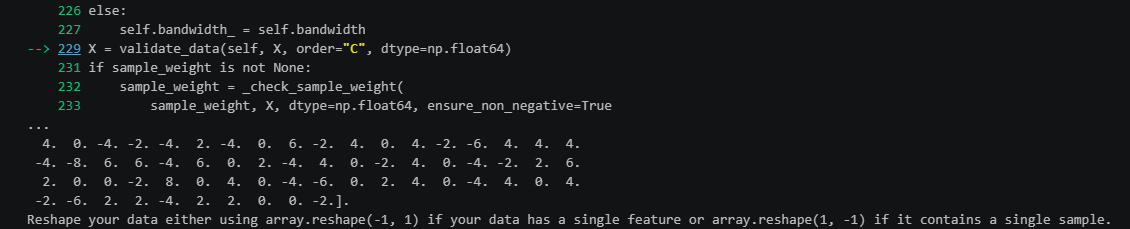


So it goes to show how Scikit's KernelDensity really does require a 2d array & we cater for this requirement as such:

In [17]:
trials = np.array(trials) # transition our trials from a standard python list into a numpy array that's 1d.
trials = trials.reshape(-1,1) # transitions trials from 1d to 2d matrix with num_of_trials rows (sample) and 1 column (feature) 

Our trials is all ready, now let's plot the histogram & the KDE in one plot, with the KDE over the histogram:

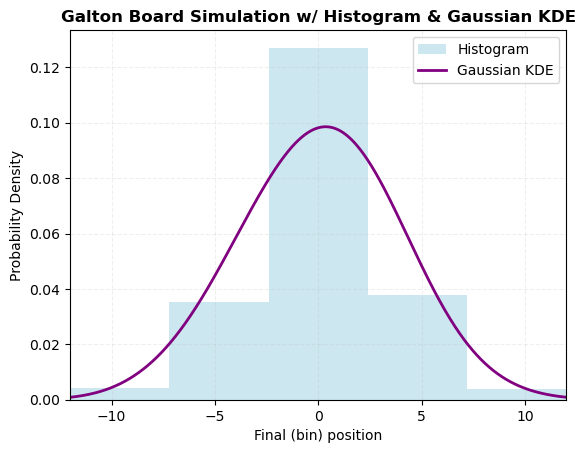

In [18]:

# initialise figure/axes:
fig,ax = plt.subplots()

bins = np.linspace(-12,12,6) # splits range of -12 to 12 into intervals, so histogram isn't plotting the actual values e.g. 2, just the counts of respective intervals between -12 & 12.

# plotting the histogram, making it semi transparent as we will just display the KDE over it:
ax.hist(trials,bins=bins,color='lightblue',alpha=.6,density=True,label="Histogram") # density param makes it so y axis shows probability density & area of all bars within histogram add to 1. 
 
# Gaussian KDE logic (i picked it over other KDE e.g. tophat, Epanechnikov etc.) + plot:
X_plot = np.linspace(-12,12,2000).reshape(-1,1) # dividing -12 to 12 into 2000 tiny intervals to help draw our curve & transform into 2d matrix w/ 2000 rows & 1 column so kde.score_samples accepts it

kde = KernelDensity(kernel='gaussian',bandwidth=2).fit(trials) # we're essentially training the non-parametric model w/ trials (a 2d matrix). Bandwith 2 helps transform our curve into a smooth one.
# KernelDensity calculuates density value for our 2000 intervals & because the ones close to the endpoints would be like 0.0000321 etc. it just takes the log of all nums start to finsh so that the
# process is less likely to face errors on computer memory storing tiny decimal points as e.g. ln(0.0000321) = -10.34665 (easier to store):
log_dens = kde.score_samples(X_plot) 
ax.plot(X_plot[:, 0],np.exp(log_dens),'purple',linewidth=2,label="Gaussian KDE") # extract first col only w/X_plot[:,0], undo logs by raising to power of e, so we plot real density values for KDE


# plot labels, title, legend etc. as required by task:
ax.set(xlim=[-12,12])
ax.set_title("Galton Board Simulation w/ Histogram & Gaussian KDE",weight="bold")
ax.set_xlabel("Final (bin) position")
ax.set_ylabel("Probability Density")
ax.legend()
ax.grid(alpha=.2,linestyle='--')

We must now think about the questions provided for us to answer in the task description. Let's start with the first one, i.e.:
1. *What is the effect on the resulting distribution of modifying the value of n - the number of experiments?*

As stated we know that n is the number of experiments/rows, so if we modify n there is obviously more/less rows for the balls to go into. Consider the case where we add just one more row, there are now numbers possible from -13 to 13 in trials as compared to -12 to 12. So notice, adding another row means that we add another -1 or 1 to our total. What does this mean? We have more rows the ball can fall into, so the affect of adding more rows, i.e. increasing n means that the distribution will be flatter and also wider as more balls are able to drift further away from the center. However, note that because p = 0.5, the peak will remain at 0 and our distribution will still be symmetric, but once again it'll be flatter and the tails will be able to extend further in our gaussian kde distribution plotted. We can verify what has been said is true by actually increasing n and plotting the graph, i.e.:

In [19]:
trials_30 = galton_process(1000,30,p)
trials_30 = np.array(trials_30).reshape(-1,1)
trials_12 = galton_process(1000,12,p)
trials_12 = np.array(trials_12).reshape(-1,1)

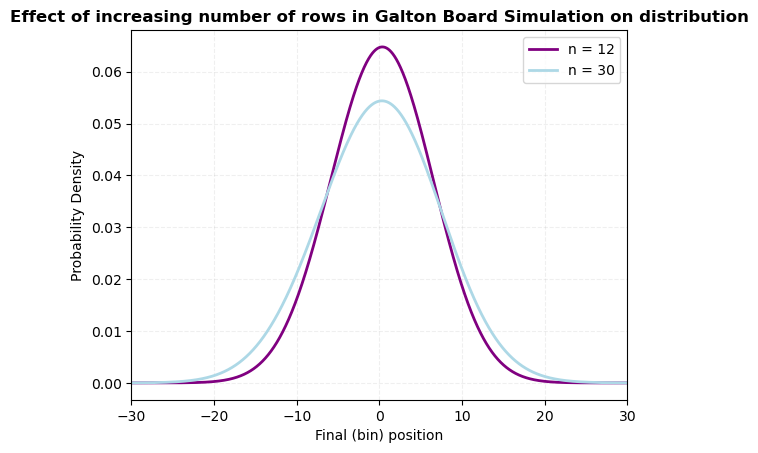

In [20]:
fig,ax = plt.subplots()
 
X_plot = np.linspace(-30,30,5000).reshape(-1,1)

kde = KernelDensity(kernel='gaussian',bandwidth=5).fit(trials_12)
log_dens = kde.score_samples(X_plot) 
ax.plot(X_plot[:, 0],np.exp(log_dens),'purple',linewidth=2,label="n = 12")


kde = KernelDensity(kernel='gaussian',bandwidth=5).fit(trials_30)
log_dens = kde.score_samples(X_plot) 
ax.plot(X_plot[:, 0],np.exp(log_dens),'lightblue',linewidth=2,label="n = 30")

ax.set(xlim=[-30,30])
ax.set_title("Effect of increasing number of rows in Galton Board Simulation on distribution",weight="bold")
ax.set_xlabel("Final (bin) position")
ax.set_ylabel("Probability Density")
ax.legend()
ax.grid(alpha=.2,linestyle='--')

On the other hand, what if we were to dicrease n i.e. number of experiments/rows? It would mean that the balls would have less amount of rows to fall into, so naturally we'd expect the distribution to be both taller as well as more narrow. Intuitively, this makes sense, if we have the same amount of balls falling, and we have less rows for them to fall into then those rows should fill up more than if we had a greater amount of rows for them to ball into.... Once again, due to p = 0.5, our distribution would still be symmetric and our peak will remain at 0 though. Let's verify what we have said through a simple plot:

In [21]:
trials_6 = galton_process(1000,6,p)
trials_6 = np.array(trials_6).reshape(-1,1)

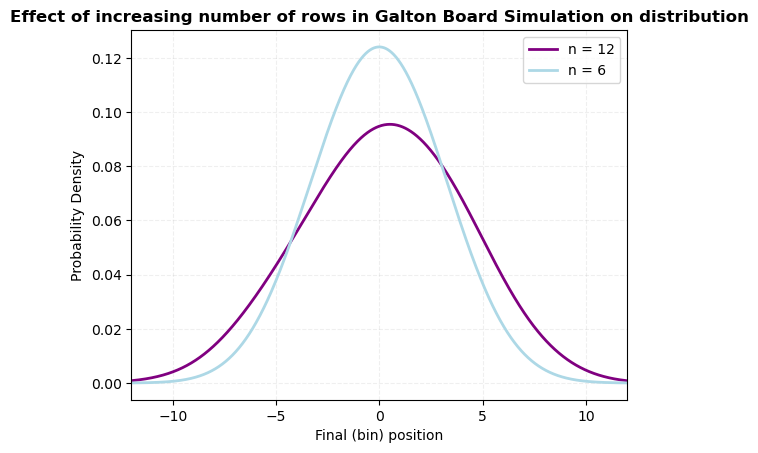

In [22]:
fig,ax = plt.subplots()
 
X_plot = np.linspace(-12,12,2000).reshape(-1,1)

kde = KernelDensity(kernel='gaussian',bandwidth=2).fit(trials_12)
log_dens = kde.score_samples(X_plot) 
ax.plot(X_plot[:, 0],np.exp(log_dens),'purple',linewidth=2,label="n = 12")


kde = KernelDensity(kernel='gaussian',bandwidth=2).fit(trials_6)
log_dens = kde.score_samples(X_plot) 
ax.plot(X_plot[:, 0],np.exp(log_dens),'lightblue',linewidth=2,label="n = 6")

ax.set(xlim=[-12,12])
ax.set_title("Effect of increasing number of rows in Galton Board Simulation on distribution",weight="bold")
ax.set_xlabel("Final (bin) position")
ax.set_ylabel("Probability Density")
ax.legend()
ax.grid(alpha=.2,linestyle='--')

Therefore, we can see that what was said in regards to the distribution and the effects on them by increasing/decreasing r are correct.

2. *What is the effect on the resulting distribution of modifying the value of p - the probability of a positive resulting in the experiment?*

When we change p by either increasing it decreasing it, the skew of our distribution is changed, i.e. the position of the kde plot is changed. Note that the overall shape of the distribution still remains the same unlike when n was changed in our previous part of this question. 

Let's first take a look at what happens when we decrease p. Think about what p means again from the task description, p is the probability of the balls going to the right in the galton board simulation. It naturally follows that if we do decrease the probability of the balls going to the right, they'd start to fall more to the left. This is what we are doing when we decrease the p variable. Our symmetric distribution which had its peak at zero now gets positively skewed. We verify this with the plot:

In [23]:
trials_pos_skew = galton_process(1000,12,0.2)
trials_pos_skew = np.array(trials_pos_skew).reshape(-1,1)

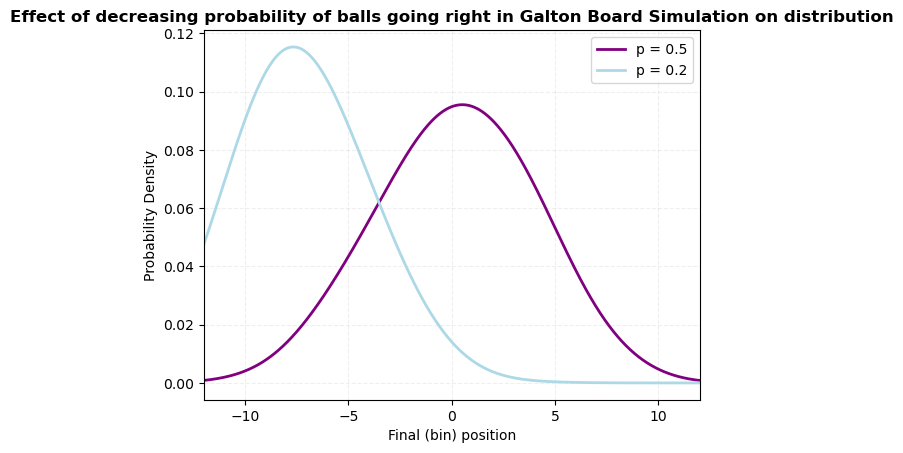

In [24]:
fig,ax = plt.subplots()
 
X_plot = np.linspace(-12,12,2000).reshape(-1,1)

kde = KernelDensity(kernel='gaussian',bandwidth=2).fit(trials_12)
log_dens = kde.score_samples(X_plot) 
ax.plot(X_plot[:, 0],np.exp(log_dens),'purple',linewidth=2,label="p = 0.5")


kde = KernelDensity(kernel='gaussian',bandwidth=2).fit(trials_pos_skew)
log_dens = kde.score_samples(X_plot) 
ax.plot(X_plot[:, 0],np.exp(log_dens),'lightblue',linewidth=2,label="p = 0.2")

ax.set(xlim=[-12,12])
ax.set_title("Effect of decreasing probability of balls going right in Galton Board Simulation on distribution",weight="bold")
ax.set_xlabel("Final (bin) position")
ax.set_ylabel("Probability Density")
ax.legend()
ax.grid(alpha=.2,linestyle='--')

Now, let's take a look at what happens when we increase p. Increasing p means that we are increasing the probability of the balls going to the right for this galton board simulation. Once again, it's obvious to us that if we do increase the probability of the balls going to the right, they will indeed go to the right more times. Hence our symmetric distribution which had the peak centered at about 0 now will be negatively skewed, and once again this is verified with the plot below:

In [25]:
trials_neg_skew = galton_process(1000,12,0.8)
trials_neg_skew = np.array(trials_neg_skew).reshape(-1,1)

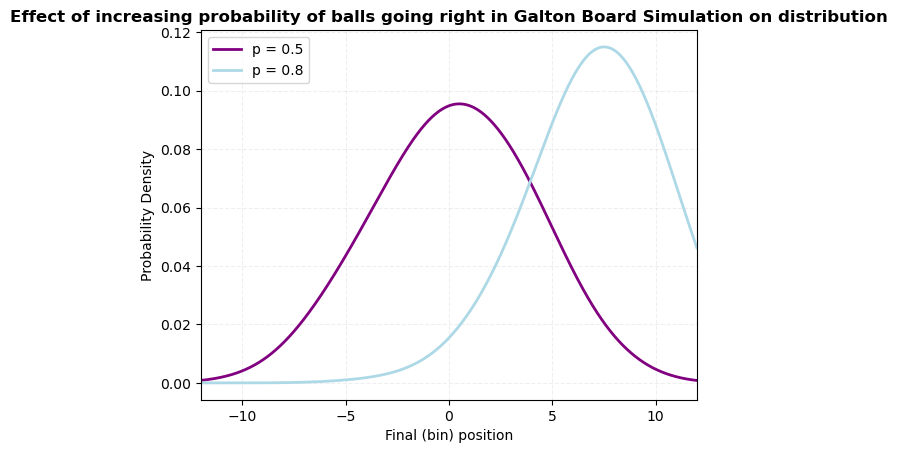

In [26]:
fig,ax = plt.subplots()
 
X_plot = np.linspace(-12,12,2000).reshape(-1,1)

kde = KernelDensity(kernel='gaussian',bandwidth=2).fit(trials_12)
log_dens = kde.score_samples(X_plot) 
ax.plot(X_plot[:, 0],np.exp(log_dens),'purple',linewidth=2,label="p = 0.5")


kde = KernelDensity(kernel='gaussian',bandwidth=2).fit(trials_neg_skew)
log_dens = kde.score_samples(X_plot) 
ax.plot(X_plot[:, 0],np.exp(log_dens),'lightblue',linewidth=2,label="p = 0.8")

ax.set(xlim=[-12,12])
ax.set_title("Effect of increasing probability of balls going right in Galton Board Simulation on distribution",weight="bold")
ax.set_xlabel("Final (bin) position")
ax.set_ylabel("Probability Density")
ax.legend()
ax.grid(alpha=.2,linestyle='--')